Figure 2: Novel pcQTL discovery. A Normalized shared variance (see Methods) explained by PC1 for correlated clusters vs neighboring genes not called as clusters, p-value from two-sample t-test. B Number of pcQTL credible sets vs number of gene clusters across tissues. C Example of credible set groups from a three gene cluster. Nodes are credible sets and edges are colored according to colocalization between the credible sets. D Number of credible set groups of each type across all clusters. E Distribution of the distance from the lead variant of each credible set to the closest TSS of any cluster gene transcript, , p-values from Mann-Whitney U test on log (|distance| + 1). F The maximum PIP-weighted | log2aFC | for any single gene in the cluster, p-values from two-sample t-test. G The CV of PIP-weighted | log2aFC | across genes in the cluster (quantifying how concentrated vs distributed the effect is), p-values from two-sample t-test.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from tqdm.auto import tqdm 
from scipy.stats import spearmanr, linregress, ttest_ind, mannwhitneyu

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import ast
import networkx as nx

tqdm.pandas()

# get outputs from a config file
prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import * 
from annotate_null_clusters import * 
from get_pcs import * 


%config InlineBackend.figure_formats = ['png']
# %matplotlib inline
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

In [51]:
# load in the pcs
pc_annotated = load_across_tissues(config, load_pc_annotated)
clusters_annotated = load_across_tissues(config, load_clusters_annotated)
cross_map_ids = clusters_annotated[clusters_annotated['has_cross_map']]['cluster_id']

# varaince for clusters
cluster_summed_var = []
for n_genes, pc_annotated_group in pc_annotated[(pc_annotated['pc_id']==1)].groupby("cluster_size"):
    cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
cluster_summed_var = np.asarray([item for sublist in cluster_summed_var for item in sublist])

/local/scratch/klawren/slrmtmp.48761844/ipykernel_63612/883511723.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
/local/scratch/klawren/slrmtmp.48761844/ipykernel_63612/883511723.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
/local/scratch/klawren/slrmtmp.48761844/ipykernel_63612/883511723.py:9: FutureWarning: The provi

In [52]:
tissue_id = 'Cells_Cultured_fibroblasts'
num_genes = 2 
expression_path = f'{config["expression_dir"]}/{tissue_id}.v8.normalized_expression.bed'
real_clusters_path = f'{config["clusters_dir"]}/{tissue_id}.clusters.txt'
covariates_path = f'{config["covariates_dir"]}/{tissue_id}.v8.covariates.txt'


expressed_genes = load_expressed_genes(expression_path)
real_clusters = pd.read_table(real_clusters_path)

expression_df = pd.read_table(expression_path)
sample_ids = expression_df.columns[4:]
expression_df_gid = expression_df.set_index('gene_id')
covariates_df = pd.read_table(covariates_path, index_col=0).T

residualized_expression = calculate_residual(expression_df[expression_df.columns[4:]], covariates_df, center=True)
residualized_expression = pd.DataFrame(residualized_expression, columns=expression_df.columns[4:], index=expression_df['gene_id'].values)

null_clusters = get_null_clusters(expressed_genes, num_genes, real_clusters)

# Generate PCs for each null cluster and calculate normalized R²
genome_summed_var = []

for idx, row in tqdm(null_clusters.iterrows(), total=len(null_clusters)):
    cluster_id = row['cluster_id']
    
    # Split cluster_id to get individual gene IDs
    gene_ids = cluster_id.split('_')
    
    # Extract expression data for genes in this null cluster
    cluster = residualized_expression.loc[gene_ids]
    
    # Perform PCA on cluster expression data
    X = cluster[sample_ids].transpose()
    pca = PCA()
    pc_values = pca.fit_transform(X)
    
    # Calculate egene R² for each PC and normalize by cluster size
    n_genes = len(cluster)
    pc_num=0
    # Calculate R² between PC and each egene in the cluster
    egene_r2_values = []
    for egene_id in gene_ids:
        egene_expression = cluster.loc[egene_id, sample_ids].to_numpy(dtype=float)
        pc_expression = pc_values[:, pc_num]
        
        # Calculate R²
        slope, intercept, r_value, p_value, std_err = linregress(pc_expression, egene_expression)
        r2 = r_value ** 2
        egene_r2_values.append(r2)
    
    # Sum R² values and normalize by cluster size
    summed_r2 = (sum(egene_r2_values) - 1) / (n_genes - 1)
    
    genome_summed_var.append(summed_r2)

print(f"Generated {len(genome_summed_var)} normalized R² values for null clusters")
genome_summed_var = np.asarray(genome_summed_var)

100%|███████████████████████████████████████████████████████████████████| 13454/13454 [00:52<00:00, 257.89it/s]

Generated 13454 normalized R² values for null clusters


In [53]:
susie_annotated = load_across_tissues(config, load_susie_annotated)
clusters = load_across_tissues(config, load_cluster)

pcqtl_cs_counts = susie_annotated[susie_annotated['type'] == 'pcqtl'].groupby(['tissue_id']).agg({'cs_id':'nunique'})
cluster_counts = clusters.groupby('tissue_id').agg({'cluster_id':'nunique'})
cs_counts = pd.merge(cluster_counts, pcqtl_cs_counts, on='tissue_id').reset_index()

In [56]:
def get_gene_name(gene_id):
    try:
        return gid_gencode.loc[gene_id]['gene_name']
    except KeyError:
        return gene_id
    
gid_gencode = load_gencode()

# get example group
# ENSG00000099974.7_ENSG00000133433.10_ENSG00000240972.1
i = underlying_signals[underlying_signals['num_e_coloc'] > 2].index[24]
# 24
my_cluster_id = underlying_signals.iloc[i]['cluster_id']
my_tissue_id = underlying_signals.iloc[i]['tissue_id']
underlying_signals[(underlying_signals['cluster_id']==my_cluster_id) & (underlying_signals['tissue_id'] == my_tissue_id)]

# pairs for this cluster
cluster_pairs = pair_coloc[(pair_coloc['cluster_id'] == my_cluster_id) & (pair_coloc['tissue_id'] == my_tissue_id)]
cluster_pairs['qtl1_id_short'] = np.where(cluster_pairs['qtl1_id'].str.contains('_e_'), cluster_pairs['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs['qtl2_id_short'] = np.where(cluster_pairs['qtl2_id'].str.contains('_e_'), cluster_pairs['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs['qtl1_id_short'] = cluster_pairs['qtl1_id_short'].apply(get_gene_name) + '-cs' + cluster_pairs['idx1'].astype(str)
cluster_pairs['qtl2_id_short'] = cluster_pairs['qtl2_id_short'].apply(get_gene_name)+ '-cs' + cluster_pairs['idx2'].astype(str)

# Create an undirected graph
G = nx.Graph()

# Add edges to the graph with weights
for index, row in cluster_pairs.iterrows():
    G.add_edge(row['qtl1_id_short'], row['qtl2_id_short'], weight=row['PP.H4.abf'])

# Get edge weights for thickness
edge_weights = [G[u][v]['weight']*5 for u, v in G.edges()]

edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['eQTL only'] if not 'PC' in node else qtl_palette['pcQTL only'] for node in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 4)) 

pos = nx.spring_layout(G, k=1.5)  
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, alpha=0.6, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.5, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, bbox= dict(facecolor='white', alpha=0.5, edgecolor='k'))
ax.axis('off')  # Turn off the axis

# Create legend
purple_patch = mpatches.Patch(color='k', alpha=0.5, label='colocalized \n(pp4) > 0.75)')
gray_patch = mpatches.Patch(color='gray', alpha=0.5, label='not colocalized \n(pp4) < 0.75)')
ax.legend(handles=[purple_patch, gray_patch], loc='upper right', frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.savefig(f"/home/klawren/oak/pcqtls/workflow/notebooks/figures/figure_2_graph.pdf", transparent=True)

plt.show()

In [57]:
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['pcQTL'] = qtl_signal_groups['num_pc_coloc'] > 0
qtl_signal_groups['eQTL'] = qtl_signal_groups['num_e_coloc'] > 0
qtl_signal_groups['exclusive_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

dict_keys(['matrix', 'shading', 'totals', 'intersections'])


FileNotFoundError: [Errno 2] No such file or directory: '/home/klawren/oak/pcqtls/workflow/notebooks/figures/figure_2_upset.pdf'

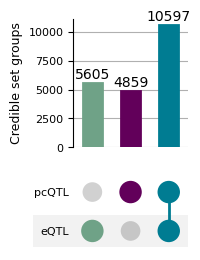

In [58]:
plt.rcParams.update({'font.size': 10})

upset = qtl_signal_groups.set_index('eQTL').set_index('pcQTL', append=True)
fig = plt.figure(figsize=(2,3))
upset = up.UpSet(upset, intersection_plot_elements=3, totals_plot_elements = 0, show_counts=True, element_size=None)  # disable the default bar chart
#upset.add_stacked_bars(by="multiple_e_color_label", title="Count", elements=4, colors=('lightgrey', '#67AFD2','#016895'))
upset.style_subsets(present=["eQTL"], absent=["pcQTL"], facecolor=qtl_palette['eQTL only'], linewidth=2)
upset.style_subsets(present=["pcQTL"], absent=["eQTL"], facecolor=qtl_palette['pcQTL only'], linewidth=2)
upset.style_subsets(present=["eQTL", "pcQTL"], facecolor=qtl_palette['Both'], linewidth=2)

# style the instersection plot
plot_result = upset.plot(fig=fig)
print(plot_result.keys())

plot_result['intersections'].set_ylabel("Credible set groups")

plt.savefig("/home/klawren/oak/pcqtls/workflow/main_figures/figures/figure_2_upset.pdf", transparent=True)
plt.grid(False)
plt.show()
plt.rcParams.update({'font.size': 7})

In [3]:
# Load GENCODE annotations
print("Loading GENCODE annotations...")
gid_gencode = pd.read_table(f"{config['working_dir']}/{config["gencode_path"]}").set_index('gene_id')
print(f"Loaded {len(gid_gencode)} genes from GENCODE")
gid_gencode['tss_pos'] = gid_gencode['tss_pos'].apply(literal_eval)

# Load SuSiE credible sets for eQTLs and pcQTLs
print("Loading SuSiE credible sets...")
eqtl_susie = load_across_tissues(config, load_e_susie_r)
pcqtl_susie = load_across_tissues(config, load_pc_susie_r)

print(f"Loaded {len(eqtl_susie)} eQTL credible set variants")
print(f"Loaded {len(pcqtl_susie)} pcQTL credible set variants")

# Function to extract lead variant (max PIP) for each credible set
def get_lead_variants(susie_df):
    # Group by phenotype_id and cs_id, find max PIP
    lead_variants = susie_df.loc[susie_df.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['pip'].idxmax()].copy()
    lead_variants['cluster_id'] = lead_variants['phenotype_id'].str.split('_e_').str[0].str.split('_pc').str[0]
    lead_variants['variant_pos'] = lead_variants['variant_id'].str.split('_').str[1].astype(int)
    return lead_variants

# Extract lead variants
eqtl_leads = get_lead_variants(eqtl_susie)
pcqtl_leads = get_lead_variants(pcqtl_susie)

print(f"Found {len(eqtl_leads)} eQTL lead variants")
print(f"Found {len(pcqtl_leads)} pcQTL lead variants")

eqtl_leads = eqtl_leads.drop_duplicates(subset=['variant_id'])
pcqtl_leads = pcqtl_leads.drop_duplicates(subset=['variant_id'])

print(f"Found {len(eqtl_leads)} unique eQTL lead variants")
print(f"Found {len(pcqtl_leads)} unique pcQTL lead variants")

def get_tss_distribution(qtl_leads, gid_gencode, match_egene=False, rolling_window=1000):
        qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')

        # add in gene tss information
        qtl_leads_exploded = pd.merge(qtl_leads.explode('gene_id'), gid_gencode.explode('tss_pos'), left_on='gene_id', right_on='gene_id', how='left')
        # annotate distance (positive or negative based on strand)
        qtl_leads_exploded['tss_dist'] = np.where(qtl_leads_exploded['strand'] == '+', 
                qtl_leads_exploded['tss_pos'] - qtl_leads_exploded['variant_pos'], 
                qtl_leads_exploded['variant_pos'] - qtl_leads_exploded['tss_pos'])
                
        if match_egene:
                qtl_leads_exploded['egene_id'] = qtl_leads_exploded['phenotype_id'].str.split('_e_').str[1]
                qtl_leads_exploded_egene_matched = qtl_leads_exploded[qtl_leads_exploded['egene_id'] == qtl_leads_exploded['gene_id']]

                # get the closest tss distance for the egene for each credible set
                qtl_min_distance = qtl_leads_exploded_egene_matched.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
        else:
                # get the closest tss distance for each credible set
                qtl_min_distance = qtl_leads_exploded.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
        qtl_counts, dist_bin_edges = np.histogram(qtl_min_distance, bins=np.arange(qtl_min_distance.min(), qtl_min_distance.max(), 1))
        qtl_counts = pd.DataFrame({'qtl_counts':qtl_counts, 'tss_distance':dist_bin_edges[:-1]})
        qtl_counts['rolling_qtl_density'] = qtl_counts['qtl_counts'].rolling(rolling_window).mean()/qtl_counts['qtl_counts'].sum()
        qtl_counts['adjusted_tss_distance'] = qtl_counts['tss_distance'] - (rolling_window/2)

        return qtl_counts, qtl_min_distance

rolling_window = 100
pcqtl_counts, pcqtl_min_dist = get_tss_distribution(pcqtl_leads, gid_gencode, match_egene=False, rolling_window=rolling_window)
eqtl_counts, eqtl_min_dist = get_tss_distribution(eqtl_leads, gid_gencode, match_egene=False, rolling_window=rolling_window)
eqtl_matched_egene_counts, eqtl_matched_egene_min_dist = get_tss_distribution(eqtl_leads, gid_gencode, match_egene=True, rolling_window=rolling_window)



Loading GENCODE annotations...
Loaded 19817 genes from GENCODE


Loading SuSiE credible sets...
Loaded 455306 eQTL credible set variants
Loaded 443922 pcQTL credible set variants
Found 19166 eQTL lead variants
Found 18149 pcQTL lead variants
Found 13758 unique eQTL lead variants
Found 13457 unique pcQTL lead variants


In [4]:
# add in pcqtl that are not found as eqtl
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['qtl_cs_id'] = qtl_signal_groups['signal_id'].str.split('-')
qtl_signals_groups_exploded = qtl_signal_groups.explode('qtl_cs_id')


pcqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_e_coloc'] == 0]
pcqtl_leads['qtl_cs_id'] = pcqtl_leads['phenotype_id'] + '_cs_' + pcqtl_leads['cs_id'].astype(str)
pcqtl_only_leads = pcqtl_leads[pcqtl_leads['qtl_cs_id'].isin(pcqtl_only_signal_groups['qtl_cs_id'])]
pcqtl_only_counts, pcqtl_only_min_dist = get_tss_distribution(pcqtl_only_leads, gid_gencode, match_egene=False, rolling_window=rolling_window)

eqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_pc_coloc'] == 0]
eqtl_leads['qtl_cs_id'] = eqtl_leads['phenotype_id'] + '_cs_' + eqtl_leads['cs_id'].astype(str)
eqtl_only_leads = eqtl_leads[eqtl_leads['qtl_cs_id'].isin(eqtl_only_signal_groups['qtl_cs_id'])]
eqtl_only_counts, eqtl_only_min_dist = get_tss_distribution(eqtl_only_leads, gid_gencode, match_egene=False, rolling_window=rolling_window)

both_signal_groups = qtl_signals_groups_exploded[(qtl_signals_groups_exploded['num_e_coloc'] > 0) & (qtl_signals_groups_exploded['num_pc_coloc'] > 0)]
both_leads = pd.concat([pcqtl_leads[pcqtl_leads['qtl_cs_id'].isin(both_signal_groups['qtl_cs_id'])], eqtl_leads[eqtl_leads['qtl_cs_id'].isin(both_signal_groups['qtl_cs_id'])]])
both_counts, both_min_dist = get_tss_distribution(both_leads, gid_gencode, match_egene=False, rolling_window=rolling_window)

/local/scratch/klawren/slrmtmp.48776383/ipykernel_19961/1020976574.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')
/local/scratch/klawren/slrmtmp.48776383/ipykernel_19961/1020976574.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')


In [7]:
stat1, p1 = mannwhitneyu(np.log10(pcqtl_only_min_dist.abs() + 1), 
                         np.log10(eqtl_only_min_dist.abs() + 1), 
                         alternative='two-sided')
print(f"pcQTL vs eQTL:")
print(f"  Mann-Whitney U test p-value: {p1:.2e}")
print(f"  Significant difference: {'Yes' if p1 < 0.05 else 'No'}")


stat1, p1 = mannwhitneyu(np.log10(pcqtl_only_min_dist.abs() + 1), 
                         np.log10(both_min_dist.abs() + 1), 
                         alternative='two-sided')
print(f"pcQTL vs both:")
print(f"  Mann-Whitney U test p-value: {p1:.2e}")
print(f"  Significant difference: {'Yes' if p1 < 0.05 else 'No'}")

stat1, p1 = mannwhitneyu(np.log10(eqtl_only_min_dist.abs() + 1), 
                         np.log10(both_min_dist.abs() + 1), 
                         alternative='two-sided')
print(f"eQTL vs both:")
print(f"  Mann-Whitney U test p-value: {p1:.2e}")
print(f"  Significant difference: {'Yes' if p1 < 0.05 else 'No'}")

pcQTL vs eQTL:
  Mann-Whitney U test p-value: 3.57e-02
  Significant difference: Yes
pcQTL vs both:
  Mann-Whitney U test p-value: 2.35e-33
  Significant difference: Yes
eQTL vs both:
  Mann-Whitney U test p-value: 7.11e-23
  Significant difference: Yes


In [ ]:
pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')

eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')

susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()
susie_explode = susie.explode('gene_id')

In [ ]:
# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()


# group over genes in a cluster that a credible set impacts
cluster_grouped_afc = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std'), 
    max_afc=('abs_pip_afc_weighted', 'max')).reset_index()

cluster_grouped_afc['cv_afc'] =  cluster_grouped_afc['std_afc'] / cluster_grouped_afc['mean_afc'] * 100

# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
cluster_grouped_afc['cs_phenotype_id'] = cluster_grouped_afc['phenotype_id'] + '_cs_' + cluster_grouped_afc['cs_id'].astype(str)
cluster_grouped_afc = pd.merge(cluster_grouped_afc, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')
cluster_grouped_afc['qtl_group_label'] = np.where((cluster_grouped_afc['num_e_coloc'] > 0), np.where((cluster_grouped_afc['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

# add pc order information 
cluster_grouped_afc['pc_num'] = np.where(cluster_grouped_afc['phenotype_id'].str.contains('_pc'), cluster_grouped_afc['phenotype_id'].str.split('_pc').str[-1], 0).astype(int)
cluster_grouped_afc['num_genes'] = cluster_grouped_afc['cluster_id'].str.split('_').apply(len)
cluster_grouped_afc['pc_order'] = np.where(cluster_grouped_afc['pc_num']==0, 'eqtl', 
            np.where(cluster_grouped_afc['pc_num'] == 1, 'first',
            np.where(cluster_grouped_afc['pc_num'] == cluster_grouped_afc['num_genes'], 'last', 'middle')))

primary_pc_afc = cluster_grouped_afc[cluster_grouped_afc['pc_order'].isin(['eqtl', 'first'])]
primary_pc_afc.groupby('qtl_group_label').agg(median_max_afc=('max_afc', 'median'), median_cv_afc=('cv_afc', 'median')).reset_index()

/local/scratch/klawren/slrmtmp.48761844/ipykernel_63612/609994014.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(['correlated', 'uncorrelated'], rotation=-45, ha='center')


Panel A p-value: 0.00e+00
Both, eQTL only p=1.97e-203
Both, pcQTL only p=1.46e-98
eQTL only, pcQTL only p=1.40e-03
Both, eQTL only p=5.94e-19
Both, pcQTL only p=1.86e-05
eQTL only, pcQTL only p=3.59e-18


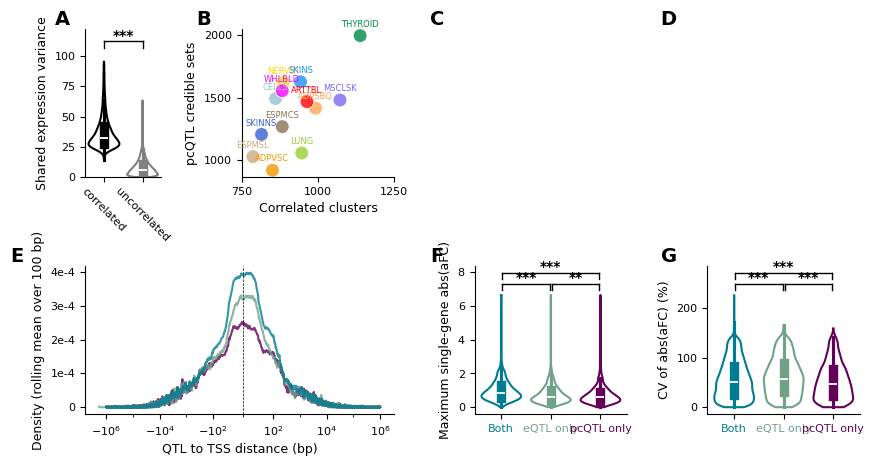

In [75]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 5))

# Create a 2x4 grid using GridSpec
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.6, wspace=0.6, width_ratios=[.5, 1, 1, 1], height_ratios=[1, 1])

# Panel A: Normalized shared variance (top left)
ax_a = fig.add_subplot(gs[0, 0])
sns.violinplot({'Clusters':cluster_summed_var, 'Non-cluster pairs':genome_summed_var}, 
                ax=ax_a, palette=['k', 'grey'], fill=False, cut=0)
ax_a.set_ylim((-.02,1.02))
ax_a.set_yticks([0, .25,.50, .75, 1])
ax_a.set_yticklabels([0, 25, 50, 75, 100])
ax_a.set_ylabel("Shared expression variance")
ax_a.spines[['right', 'top']].set_visible(False)
ax_a.set_xticklabels(['correlated', 'uncorrelated'], rotation=-45, ha='center')

# Add statistical significance for panel A
from scipy.stats import ttest_ind
stat, pval = ttest_ind(cluster_summed_var, genome_summed_var)
print(f"Panel A p-value: {pval:.2e}")

y_max = 1.02
y_pos = y_max * 1.1
x1, x2 = 0, 1
ax_a.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=1)
ax_a.plot([x1, x1], [y_pos, y_pos*0.95], 'k-', linewidth=1)
ax_a.plot([x2, x2], [y_pos, y_pos*0.95], 'k-', linewidth=1)

# Add p-value text
if pval < 0.001:
    sig_text = '***'
elif pval < 0.01:
    sig_text = '**'
elif pval < 0.05:
    sig_text = '*'
else:
    sig_text = 'ns'

ax_a.text((x1+x2)/2, y_pos*.99, sig_text, ha='center', va='bottom', fontweight='bold')
ax_a.set_ylim(0, y_max * 1.2)  # Adjust ylim to accommodate significance bars

ax_a.text(-.2, 1, 'A', transform=ax_a.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel B: Number of pcQTL credible sets vs number of gene clusters across tissues (top middle-left)
ax_b = fig.add_subplot(gs[0, 1:2])
sns.scatterplot(cs_counts, y='cs_id', x='cluster_id', hue='tissue_id', 
                palette=gtex_tissue_pal, ax=ax_b, s=100, alpha=.8, legend=False)

# Add tissue labels to each point with better positioning to avoid overlap
for idx, row in cs_counts.iterrows():
    tissue_id = row['tissue_id']
    color = gtex_tissue_dict[tissue_id]
    # Get the abbreviated tissue name
    tissue_abbrev = gtex_tissue_abbrev[list(gtex_tissue_dict.keys()).index(tissue_id)]
    
    # Position labels centered above the points
    ax_b.annotate(tissue_abbrev, 
                  xy=(row['cluster_id'], row['cs_id']),
                  xytext=(0, 5), textcoords='offset points',
                  fontsize=6, color=color, ha='center', va='bottom')

ax_b.set_xlabel('Correlated clusters')
ax_b.set_ylabel('pcQTL credible sets')
ax_b.set_yticks([1000, 1500, 2000])
ax_b.set_xticks([750, 1000, 1250])
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.text(-.2, 1, 'B', transform=ax_b.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel C: Example of credible set groups from a three gene cluster 
ax_c = fig.add_subplot(gs[0, 2])

ax_c.set_xlim(0, 1)
ax_c.set_ylim(0, 1)
ax_c.axis('off')
ax_c.text(-.2, 1, 'C', transform=ax_c.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel D: Number of credible set groups of each type across all clusters
ax_d = fig.add_subplot(gs[0, 3])

ax_d.set_xlim(0, 1)
ax_d.set_ylim(0, 1)
ax_d.axis('off')
ax_d.text(-.2, 1, 'D', transform=ax_d.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')


# Panel E: TSS distance distribution 
ax_e = fig.add_subplot(gs[1, 0:2])
sns.lineplot(x='adjusted_tss_distance', y='rolling_qtl_density', data=pcqtl_only_counts, 
             color=qtl_colors['pcQTL'], ax=ax_e, alpha=.8)
sns.lineplot(x='adjusted_tss_distance', y='rolling_qtl_density', data=eqtl_only_counts, 
             color=qtl_colors['eQTL'], ax=ax_e, alpha=.8)
sns.lineplot(x='adjusted_tss_distance', y='rolling_qtl_density', data=both_counts, 
             color=qtl_palette['Both'], ax=ax_e, alpha=.8)
ax_e.set_xscale('symlog', linthresh=rolling_window)
ax_e.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
ax_e.set_xlabel('QTL to TSS distance (bp)')
ax_e.set_ylabel('Density (rolling mean over 100 bp)')
ax_e.spines[['top', 'right']].set_visible(False)
ax_e.set_xticks([-1e6, -1e4, -1e2, 1e2, 1e4, 1e6])
ax_e.text(-.2, 1, 'E', transform=ax_e.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')
ax_e.set_yticks([0, 0.0001, 0.0002, 0.0003, 0.0004])
ax_e.set_yticklabels(['0', '1e-4', '2e-4', '3e-4', '4e-4'])

# Panel F: Maximum PIP-weighted marginal effect
ax_f = fig.add_subplot(gs[1, 2])
sns.violinplot(data=primary_pc_afc, x='qtl_group_label', y='max_afc',
               hue='qtl_group_label', palette=qtl_palette, ax=ax_f, cut=0,
               inner='box', linewidth=1.5, saturation=0.8, fill=False)
ax_f.spines[['right', 'top']].set_visible(False)
ax_f.set_ylabel('Maximum single-gene abs(aFC)')
ax_f.set_yticks([0, 2, 4, 6, 8])

add_statistical_significance(ax_f, primary_pc_afc, 'qtl_group_label', 'max_afc', palette=qtl_palette)
ax_f.text(-.2, 1, 'F', transform=ax_f.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')
ax_f.set_xlabel('')
for i, tick_label in enumerate(ax_f.get_xticklabels()):
    group_name = tick_label.get_text()
    if group_name in qtl_palette:
        tick_label.set_color(qtl_palette[group_name])

# Panel G: Coefficient of variation of aFC 
ax_g = fig.add_subplot(gs[1, 3])
sns.violinplot(data=primary_pc_afc, x='qtl_group_label', y='cv_afc',
               hue='qtl_group_label', palette=qtl_palette, ax=ax_g, cut=0,
               inner='box', linewidth=1.5, saturation=0.8, fill=False)
ax_g.spines[['right', 'top']].set_visible(False)
ax_g.set_ylabel('CV of abs(aFC) (%)')
ax_g.set_xlabel('')
ax_g.set_yticks([0, 100, 200, 300])


add_statistical_significance(ax_g, primary_pc_afc, 'qtl_group_label', 'cv_afc', palette=qtl_palette)
ax_g.text(-.2, 1, 'G', transform=ax_g.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')
for i, tick_label in enumerate(ax_g.get_xticklabels()):
    group_name = tick_label.get_text()
    if group_name in qtl_palette:
        tick_label.set_color(qtl_palette[group_name])

plt.savefig(f"{config['working_dir']}/workflow/main_figures/figures/figure_2_combined.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()